### Parameters

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# ── Physical parameters ──────────────────────────────────────
lam = 633e-9          # wavelength [m] — HeNe laser
f   = 0.1             # focal length [m]

# ── Slit nominal state ───────────────────────────────────────
a0  = 0.5e-3          # nominal slit width [m]
c0  = 0.0             # nominal slit center [m]

# ── Screen ───────────────────────────────────────────────────
x   = np.linspace(-5e-3, 5e-3, 1000)   # screen coordinates [m]

# ── ROI on screen ────────────────────────────────────────────
roi_left  = -0.5e-3   # [m]
roi_right =  0.5e-3   # [m]
roi_mask  = (x >= roi_left) & (x <= roi_right)

# ── Simulation time ──────────────────────────────────────────
dt   = 1e-3           # timestep [s]
T    = 30.0            # total time [s]
time = np.arange(0, T, dt)

print(f"Fresnel number at nominal width: {a0**2 / (lam * f):.1f}")
print(f"Screen range: {x[0]*1e3:.1f} mm to {x[-1]*1e3:.1f} mm")
print(f"ROI: {roi_left*1e3:.1f} mm to {roi_right*1e3:.1f} mm")
print(f"Timesteps: {len(time)}")

Fresnel number at nominal width: 3.9
Screen range: -5.0 mm to 5.0 mm
ROI: -0.5 mm to 0.5 mm
Timesteps: 30000


### Disturbance Model

In [42]:
# ── Intensity at focal plane ─────────────────────────────────
def intensity(x, a, c, lam, f):
    u = a * (x - c) / (lam * f)
    return (a**2 / a0**2) * np.sinc(u)**2

# ── Disturbance model ────────────────────────────────────────
A_a  = 0.1e-3   # width jerk amplitude [m]
f_a  = 2.0      # width disturbance frequency [Hz]

A_c  = 0.3e-3   # position jerk amplitude [m]
f_c  = 1.5      # position disturbance frequency [Hz]
phi  = np.pi/4  # phase offset between the two disturbances

noise_std = 0.02e-3  # small additive noise std [m]

def disturbed_slit(t):
    a = a0 + A_a * np.sin(2*np.pi*f_a*t) + np.random.normal(0, noise_std)
    c = c0 + A_c * np.sin(2*np.pi*f_c*t + phi) + np.random.normal(0, noise_std)
    a = float(np.clip(a, 0.05e-3, 2e-3))

    return a, c

# ── Quick sanity check ───────────────────────────────────────
a_test, c_test = disturbed_slit(0.0)
I_test = intensity(x, a_test, c_test, lam, f)
print(f"Test slit: width={a_test*1e3:.3f} mm, center={c_test*1e3:.3f} mm")
print(f"Peak intensity: {I_test.max():.4f}")
print(f"ROI mean intensity: {I_test[roi_mask].mean():.4f}")

Test slit: width=0.502 mm, center=0.223 mm
Peak intensity: 1.0056
ROI mean intensity: 0.1227


### Open Loop Approach

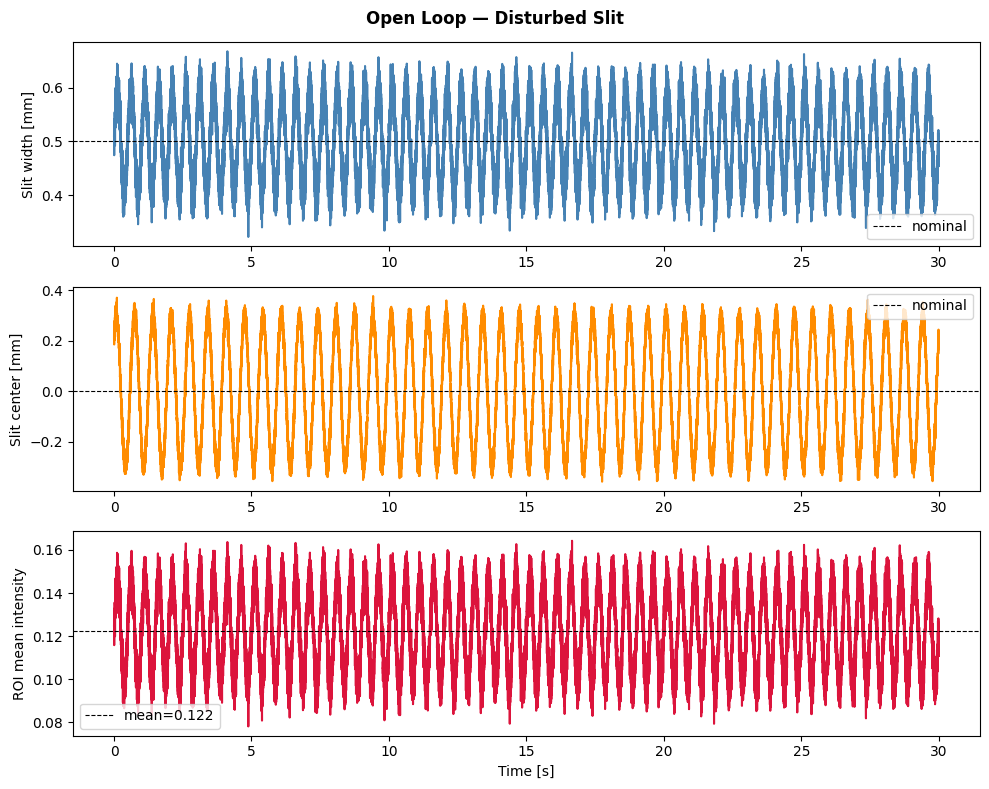

ROI mean: 0.1224, min: 0.0781, max: 0.1643


In [29]:
# ── Open loop simulation ─────────────────────────────────────
np.random.seed(42)

a_log     = np.zeros(len(time))
c_log     = np.zeros(len(time))
roi_log   = np.zeros(len(time))

for i, t in enumerate(time):
    a, c       = disturbed_slit(t)
    I          = intensity(x, a, c, lam, f)
    a_log[i]   = a
    c_log[i]   = c
    roi_log[i] = I[roi_mask].mean()

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 8), tight_layout=True)

axes[0].plot(time, a_log*1e3, color='steelblue')
axes[0].axhline(a0*1e3, color='k', linestyle='--', linewidth=0.8, label='nominal')
axes[0].set_ylabel('Slit width [mm]')
axes[0].legend()

axes[1].plot(time, c_log*1e3, color='darkorange')
axes[1].axhline(0, color='k', linestyle='--', linewidth=0.8, label='nominal')
axes[1].set_ylabel('Slit center [mm]')
axes[1].legend()

axes[2].plot(time, roi_log, color='crimson')
axes[2].axhline(roi_log.mean(), color='k', linestyle='--', linewidth=0.8, label=f'mean={roi_log.mean():.3f}')
axes[2].set_ylabel('ROI mean intensity')
axes[2].set_xlabel('Time [s]')
axes[2].legend()

plt.suptitle('Open Loop — Disturbed Slit', fontweight='bold')
plt.savefig('open_loop.png', dpi=150)
plt.show()
print(f"ROI mean: {roi_log.mean():.4f}, min: {roi_log.min():.4f}, max: {roi_log.max():.4f}")

### Closed Loop Using PI Controller

In [30]:
class PID:
    def __init__(self, Kp, Ki, Kd, dt, output_min, output_max):
        self.Kp, self.Ki, self.Kd = Kp, Ki, Kd
        self.dt = dt
        self.output_min = output_min
        self.output_max = output_max
        self.integral   = 0.0
        self.prev_error = 0.0

    def step(self, error):
        p = self.Kp * error
        d = self.Kd * (error - self.prev_error) / self.dt
        self.prev_error = error

        output_pd = p + d
        output_unclipped = output_pd + self.Ki * self.integral
        # anti-windup: only integrate if not saturated
        if not (output_unclipped >= self.output_max and error > 0) and \
           not (output_unclipped <= self.output_min and error < 0):
            self.integral += error * self.dt

        output = output_pd + self.Ki * self.integral
        return np.clip(output, self.output_min, self.output_max)

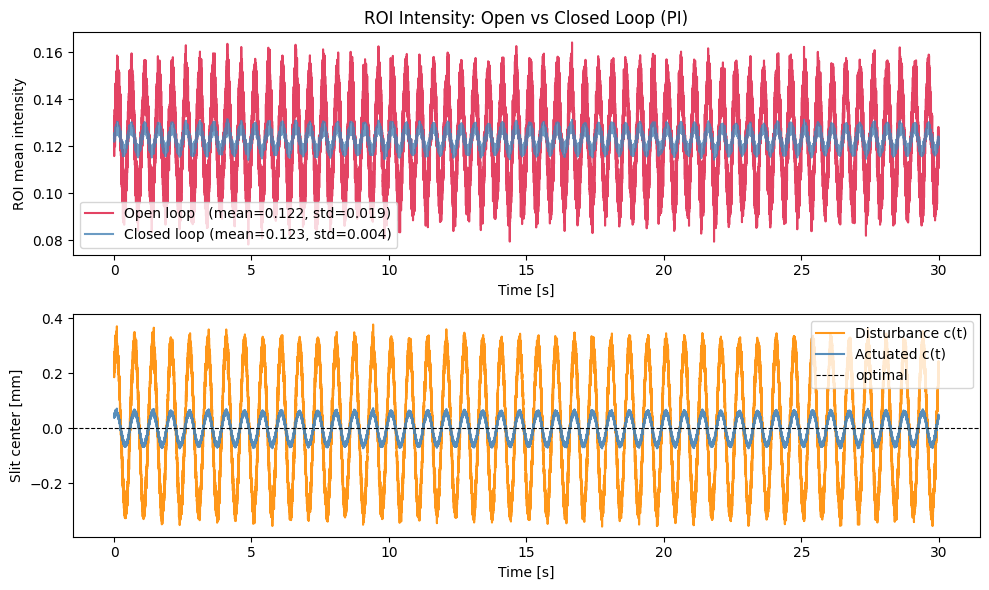

Open loop   — mean: 0.1224, std: 0.0186
Closed loop — mean: 0.1230, std: 0.0037


In [31]:
np.random.seed(42)

pid_c = PID(Kp=0.8, Ki=0.1, Kd=0.0, dt=dt,
            output_min=-0.4e-3, output_max=0.4e-3)
pid_a = PID(Kp=0.8, Ki=0.1, Kd=0.0, dt=dt,
            output_min=-0.3e-3, output_max=0.3e-3)

a_cl_log   = np.zeros(len(time))
c_cl_log   = np.zeros(len(time))
c_act_log  = np.zeros(len(time))
roi_cl_log = np.zeros(len(time))

for i, t in enumerate(time):
    a_dist, c_dist = disturbed_slit(t)

    e_c = 0.0 - c_dist
    e_a = a0  - a_dist

    u_c = pid_c.step(e_c)
    u_a = pid_a.step(e_a)

    c_act = c_dist + u_c
    a_act = np.clip(a_dist + u_a, 0.05e-3, 2e-3)

    I = intensity(x, a_act, c_act, lam, f)

    a_cl_log[i]   = a_act
    c_cl_log[i]   = c_dist
    c_act_log[i]  = c_act
    roi_cl_log[i] = I[roi_mask].mean()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), tight_layout=True)

axes[0].plot(time, roi_log,    color='crimson',   alpha=0.8,
             label=f'Open loop   (mean={roi_log.mean():.3f}, std={roi_log.std():.3f})')
axes[0].plot(time, roi_cl_log, color='steelblue', alpha=0.8,
             label=f'Closed loop (mean={roi_cl_log.mean():.3f}, std={roi_cl_log.std():.3f})')
axes[0].set_ylabel('ROI mean intensity')
axes[0].set_xlabel('Time [s]')
axes[0].legend()
axes[0].set_title('ROI Intensity: Open vs Closed Loop (PI)')

axes[1].plot(time, c_cl_log*1e3,  color='darkorange', alpha=0.9, label='Disturbance c(t)')
axes[1].plot(time, c_act_log*1e3, color='steelblue',  alpha=0.9, label='Actuated c(t)')
axes[1].axhline(0, color='k', linestyle='--', linewidth=0.8, label='optimal')
axes[1].set_ylabel('Slit center [mm]')
axes[1].set_xlabel('Time [s]')
axes[1].legend()

plt.savefig('closed_loop_PI.png', dpi=150)
plt.show()

print(f"Open loop   — mean: {roi_log.mean():.4f}, std: {roi_log.std():.4f}")
print(f"Closed loop — mean: {roi_cl_log.mean():.4f}, std: {roi_cl_log.std():.4f}")

### System Identification (Static)

In [32]:
# ── Block 5: Static System Identification ────────────────────

# ── Two ROI zones ────────────────────────────────────────────
roi_L = (x >= -0.5e-3) & (x < 0.0)
roi_R = (x >= 0.0)     & (x <= 0.5e-3)

def measure(a, c):
    """Return measurement vector s = [s_L, s_R]"""
    I  = intensity(x, a, c, lam, f)
    sL = I[roi_L].mean()
    sR = I[roi_R].mean()
    return np.array([sL, sR])

# ── Nominal measurement ───────────────────────────────────────
s_nom = measure(a0, c0)
print(f"Nominal measurement: sL={s_nom[0]:.4f}, sR={s_nom[1]:.4f}")

# ── Poke amplitudes ───────────────────────────────────────────
d_c = 0.03e-3    # 10% of disturbance amplitude
d_a = 0.05e-3    # 10% of nominal width

# ── Poke actuator 1: slit center c ───────────────────────────
s_c_pos = measure(a0, c0 + d_c)
s_c_neg = measure(a0, c0 - d_c)
col_c   = (s_c_pos - s_c_neg) / (2 * d_c)   # finite difference
print(f"\nPoke c: s_pos={s_c_pos}, s_neg={s_c_neg}")
print(f"Column 1 of D: {col_c}")

# ── Poke actuator 2: slit width a ────────────────────────────
s_a_pos = measure(a0 + d_a, c0)
s_a_neg = measure(a0 - d_a, c0)
col_a   = (s_a_pos - s_a_neg) / (2 * d_a)   # finite difference
print(f"\nPoke a: s_pos={s_a_pos}, s_neg={s_a_neg}")
print(f"Column 2 of D: {col_a}")

# ── Build interaction matrix D ────────────────────────────────
D = np.column_stack([col_c, col_a])
print(f"\nInteraction matrix D:")
print(D)
print(f"\nCondition number of D: {np.linalg.cond(D):.2f}")

# ── Compute control matrix D+ (pseudoinverse) ─────────────────
D_plus = np.linalg.pinv(D)
print(f"\nControl matrix D+:")
print(D_plus)

# ── Validate: predict response to a known perturbation ────────
test_dc = 0.1e-3
test_da = 0.05e-3
s_test_actual    = measure(a0 + test_da, c0 + test_dc)
ds_test_actual   = s_test_actual - s_nom
ds_test_predicted = D @ np.array([test_dc, test_da])

print(f"\nValidation:")
print(f"Actual    ds: {ds_test_actual}")
print(f"Predicted ds: {ds_test_predicted}")
print(f"Error:        {np.abs(ds_test_actual - ds_test_predicted)}")

Nominal measurement: sL=0.1233, sR=0.1233

Poke c: s_pos=[0.06681353 0.179664  ], s_neg=[0.179664   0.06681353]
Column 1 of D: [-1880.84120369  1880.84120369]

Poke a: s_pos=[0.1357776 0.1357776], s_neg=[0.11062462 0.11062462]
Column 2 of D: [251.52975708 251.52975708]

Interaction matrix D:
[[-1880.84120369   251.52975708]
 [ 1880.84120369   251.52975708]]

Condition number of D: 7.48

Control matrix D+:
[[-0.00026584  0.00026584]
 [ 0.00198784  0.00198784]]

Validation:
Actual    ds: [-0.11232448  0.13713486]
Predicted ds: [-0.17550763  0.20066061]
Error:        [0.06318316 0.06352575]


In [33]:
test_dc = 0.01e-3
test_da = 0.01e-3
s_test_actual     = measure(a0 + test_da, c0 + test_dc)
ds_test_actual    = s_test_actual - s_nom
ds_test_predicted = D @ np.array([test_dc, test_da])

print(f"Actual    ds: {ds_test_actual}")
print(f"Predicted ds: {ds_test_predicted}")
print(f"Relative error: {np.abs(ds_test_actual - ds_test_predicted)/np.abs(ds_test_actual)*100} %")

Actual    ds: [-0.01820436  0.02314209]
Predicted ds: [-0.01629311  0.02132371]
Relative error: [10.4988298   7.85745184] %


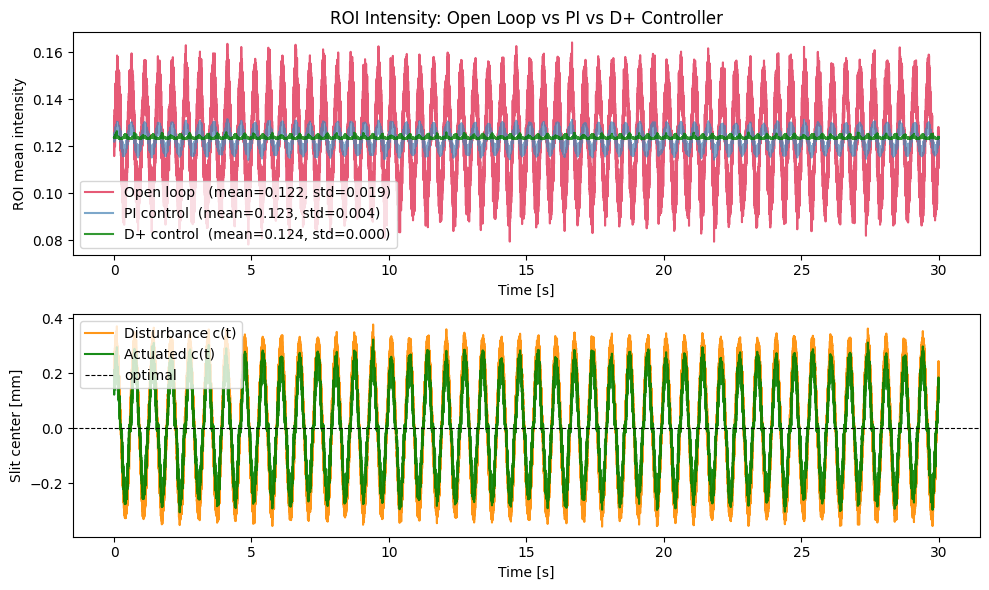

Open loop   — mean: 0.1224, std: 0.0186
PI control  — mean: 0.1230, std: 0.0037
D+ control  — mean: 0.1237, std: 0.0004


In [34]:
# ── Block 6: D+ Controller ───────────────────────────────────
np.random.seed(42)

a_dp_log   = np.zeros(len(time))
c_dp_log   = np.zeros(len(time))
c_act_log  = np.zeros(len(time))
roi_dp_log = np.zeros(len(time))

for i, t in enumerate(time):
    # step 1: disturbance moves the slit
    a_dist, c_dist = disturbed_slit(t)

    # step 2: measure current sensor output
    s_measured = measure(a_dist, c_dist)

    # step 3: compute sensor deviation from nominal
    ds = s_measured - s_nom

    # step 4: compute actuator correction via D+
    # u_cmd = [delta_c, delta_a]
    u_cmd = -D_plus @ ds

    # step 5: apply correction
    c_act = c_dist + u_cmd[0]
    a_act = np.clip(a_dist + u_cmd[1], 0.05e-3, 2e-3)

    # step 6: measure corrected intensity
    I = intensity(x, a_act, c_act, lam, f)

    a_dp_log[i]   = a_act
    c_dp_log[i]   = c_dist
    c_act_log[i]  = c_act
    roi_dp_log[i] = I[roi_mask].mean()

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 6), tight_layout=True)

axes[0].plot(time, roi_log,    color='crimson',   alpha=0.7,
             label=f'Open loop   (mean={roi_log.mean():.3f}, std={roi_log.std():.3f})')
axes[0].plot(time, roi_cl_log, color='steelblue', alpha=0.7,
             label=f'PI control  (mean={roi_cl_log.mean():.3f}, std={roi_cl_log.std():.3f})')
axes[0].plot(time, roi_dp_log, color='green',     alpha=0.8,
             label=f'D+ control  (mean={roi_dp_log.mean():.3f}, std={roi_dp_log.std():.3f})')
axes[0].set_ylabel('ROI mean intensity')
axes[0].set_xlabel('Time [s]')
axes[0].legend()
axes[0].set_title('ROI Intensity: Open Loop vs PI vs D+ Controller')

axes[1].plot(time, c_dp_log*1e3,  color='darkorange', alpha=0.9, label='Disturbance c(t)')
axes[1].plot(time, c_act_log*1e3, color='green',      alpha=0.9, label='Actuated c(t)')
axes[1].axhline(0, color='k', linestyle='--', linewidth=0.8, label='optimal')
axes[1].set_ylabel('Slit center [mm]')
axes[1].set_xlabel('Time [s]')
axes[1].legend()

plt.savefig('dplus_control.png', dpi=150)
plt.show()

print(f"Open loop   — mean: {roi_log.mean():.4f}, std: {roi_log.std():.4f}")
print(f"PI control  — mean: {roi_cl_log.mean():.4f}, std: {roi_cl_log.std():.4f}")
print(f"D+ control  — mean: {roi_dp_log.mean():.4f}, std: {roi_dp_log.std():.4f}")

### Actuator Dyanamics

Cutoff frequency (center): 1.59 Hz
Cutoff frequency (width):  1.59 Hz
alpha_c: 0.9900
alpha_a: 0.9900


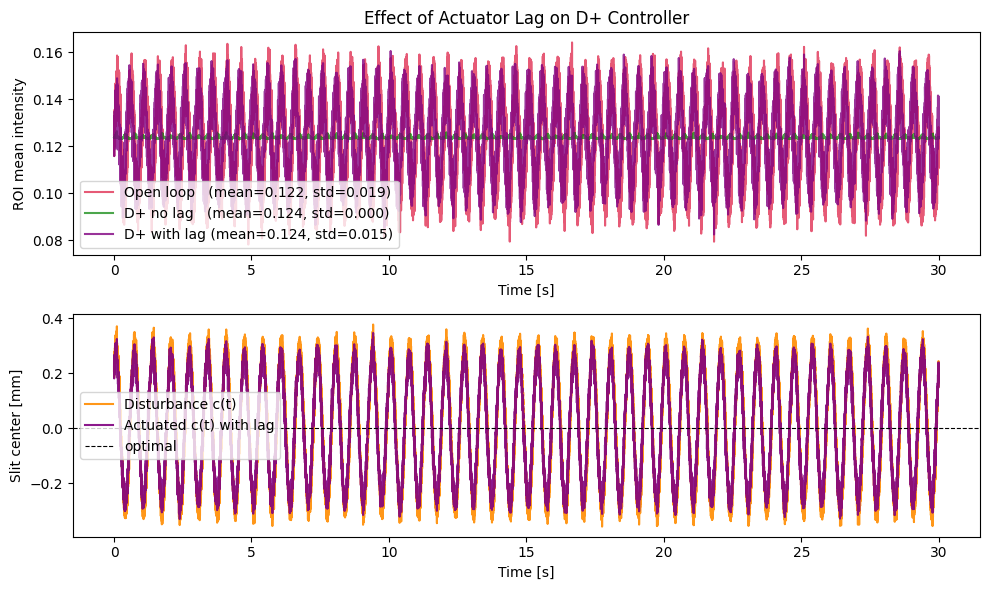

Open loop     — mean: 0.1224,    std: 0.0186
D+ no lag     — mean: 0.1237, std: 0.0004
D+ with lag   — mean: 0.1235, std: 0.0147


In [35]:
# ── Block 7: Actuator Dynamics (First Order Lag) ─────────────

tau_c = 0.1   # time constant for center actuator [s]
tau_a = 0.1   # time constant for width actuator [s]

# discrete time smoothing coefficients
alpha_c = np.exp(-dt / tau_c)
alpha_a = np.exp(-dt / tau_a)

print(f"Cutoff frequency (center): {1/(2*np.pi*tau_c):.2f} Hz")
print(f"Cutoff frequency (width):  {1/(2*np.pi*tau_a):.2f} Hz")
print(f"alpha_c: {alpha_c:.4f}")
print(f"alpha_a: {alpha_a:.4f}")

# ── Simulation with actuator lag + D+ controller ─────────────
np.random.seed(42)

# actuator states (memory of previous position)
c_actuator = 0.0
a_actuator = a0

a_lag_log   = np.zeros(len(time))
c_lag_log   = np.zeros(len(time))
c_act_log   = np.zeros(len(time))
roi_lag_log = np.zeros(len(time))

for i, t in enumerate(time):
    # step 1: disturbance moves the slit
    a_dist, c_dist = disturbed_slit(t)

    # step 2: measure current sensor output
    s_measured = measure(a_dist, c_dist)

    # step 3: compute sensor deviation from nominal
    ds = s_measured - s_nom

    # step 4: D+ computes commanded correction
    u_cmd = -D_plus @ ds

    # step 5: actuator lags behind command (first order lag)
    c_actuator = alpha_c * c_actuator + (1 - alpha_c) * u_cmd[0]
    a_actuator = alpha_a * a_actuator + (1 - alpha_a) * (a0 + u_cmd[1])

    # step 6: apply lagged actuator output
    c_act = c_dist + c_actuator
    a_act = np.clip(a_dist + (a_actuator - a0), 0.05e-3, 2e-3)

    # step 7: measure corrected intensity
    I = intensity(x, a_act, c_act, lam, f)

    a_lag_log[i]   = a_act
    c_lag_log[i]   = c_dist
    c_act_log[i]   = c_act
    roi_lag_log[i] = I[roi_mask].mean()

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 6), tight_layout=True)

axes[0].plot(time, roi_log,     color='crimson',   alpha=0.7,
             label=f'Open loop   (mean={roi_log.mean():.3f}, std={roi_log.std():.3f})')
axes[0].plot(time, roi_dp_log,  color='green',     alpha=0.7,
             label=f'D+ no lag   (mean={roi_dp_log.mean():.3f}, std={roi_dp_log.std():.3f})')
axes[0].plot(time, roi_lag_log, color='purple',    alpha=0.8,
             label=f'D+ with lag (mean={roi_lag_log.mean():.3f}, std={roi_lag_log.std():.3f})')
axes[0].set_ylabel('ROI mean intensity')
axes[0].set_xlabel('Time [s]')
axes[0].legend()
axes[0].set_title('Effect of Actuator Lag on D+ Controller')

axes[1].plot(time, c_lag_log*1e3, color='darkorange', alpha=0.9, label='Disturbance c(t)')
axes[1].plot(time, c_act_log*1e3, color='purple',     alpha=0.9, label='Actuated c(t) with lag')
axes[1].axhline(0, color='k', linestyle='--', linewidth=0.8, label='optimal')
axes[1].set_ylabel('Slit center [mm]')
axes[1].set_xlabel('Time [s]')
axes[1].legend()

plt.savefig('actuator_lag.png', dpi=150)
plt.show()

print(f"Open loop     — mean: {roi_log.mean():.4f},    std: {roi_log.std():.4f}")
print(f"D+ no lag     — mean: {roi_dp_log.mean():.4f}, std: {roi_dp_log.std():.4f}")
print(f"D+ with lag   — mean: {roi_lag_log.mean():.4f}, std: {roi_lag_log.std():.4f}")

### PSD Analysis

Frequency resolution: 0.122 Hz
Number of windows:    5


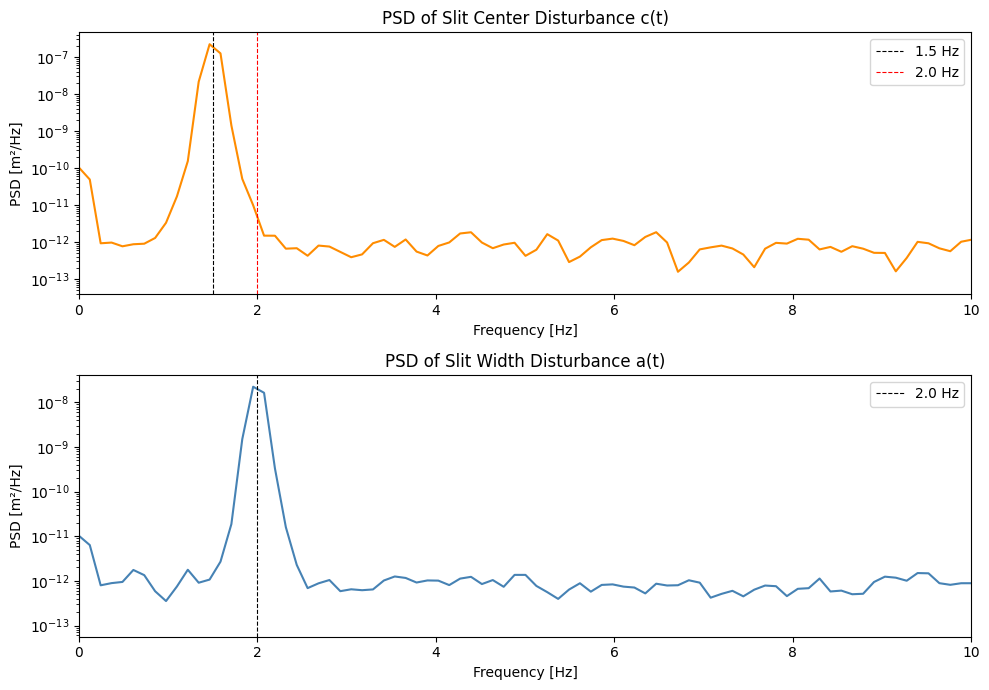


Top 3 peaks in c(t) PSD:
  f=1.465 Hz, PSD=2.21e-07
  f=494.019 Hz, PSD=2.47e-12
  f=127.808 Hz, PSD=2.44e-12

Top 3 peaks in a(t) PSD:
  f=1.953 Hz, PSD=2.24e-08
  f=25.757 Hz, PSD=2.80e-12
  f=98.877 Hz, PSD=2.74e-12


In [41]:
from scipy import signal as sig

# ── Block 8: Power Spectral Density Analysis ─────────────────

# recompute clean disturbance signal
np.random.seed(42)
c_dist_log_clean = np.zeros(len(time))
a_dist_log_clean = np.zeros(len(time))

for i, t in enumerate(time):
    a_d, c_d = disturbed_slit(t)
    c_dist_log_clean[i] = c_d
    a_dist_log_clean[i] = a_d

# ── Welch PSD ────────────────────────────────────────────────
fs       = 1/dt        # sampling frequency = 1000 Hz
nperseg  = 8192        # df = 1000/8192 = 0.122Hz
noverlap = 4096        # 50% overlap

f_c, psd_c = sig.welch(c_dist_log_clean, fs=fs, nperseg=nperseg, noverlap=noverlap)
f_a, psd_a = sig.welch(a_dist_log_clean, fs=fs, nperseg=nperseg, noverlap=noverlap)

print(f"Frequency resolution: {fs/nperseg:.3f} Hz")
print(f"Number of windows:    {(len(c_dist_log_clean) - nperseg)//(nperseg - noverlap)}")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 7), tight_layout=True)

axes[0].semilogy(f_c, psd_c, color='darkorange')
axes[0].axvline(1.5, color='k', linestyle='--', linewidth=0.8, label='1.5 Hz')
axes[0].axvline(2.0, color='r', linestyle='--', linewidth=0.8, label='2.0 Hz')
axes[0].set_xlim(0, 10)
axes[0].set_xlabel('Frequency [Hz]')
axes[0].set_ylabel('PSD [m²/Hz]')
axes[0].set_title('PSD of Slit Center Disturbance c(t)')
axes[0].legend()

axes[1].semilogy(f_a, psd_a, color='steelblue')
axes[1].axvline(2.0, color='k', linestyle='--', linewidth=0.8, label='2.0 Hz')
axes[1].set_xlim(0, 10)
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('PSD [m²/Hz]')
axes[1].set_title('PSD of Slit Width Disturbance a(t)')
axes[1].legend()

plt.savefig('psd_analysis.png', dpi=150)
plt.show()

# ── Find peaks ───────────────────────────────────────────────
peaks_c, props_c = sig.find_peaks(psd_c, height=1e-12)
peaks_a, props_a = sig.find_peaks(psd_a, height=1e-13)

print("\nTop 3 peaks in c(t) PSD:")
top3_c = np.argsort(props_c['peak_heights'])[-3:][::-1]
for idx in top3_c:
    print(f"  f={f_c[peaks_c[idx]]:.3f} Hz, PSD={props_c['peak_heights'][idx]:.2e}")

print("\nTop 3 peaks in a(t) PSD:")
top3_a = np.argsort(props_a['peak_heights'])[-3:][::-1]
for idx in top3_a:
    print(f"  f={f_a[peaks_a[idx]]:.3f} Hz, PSD={props_a['peak_heights'][idx]:.2e}")

### Designing LQG Controller

Kalman gain K_kal:
[[0.990204 0.      ]
 [0.913375 0.      ]
 [0.       0.618345]
 [0.       0.503262]]


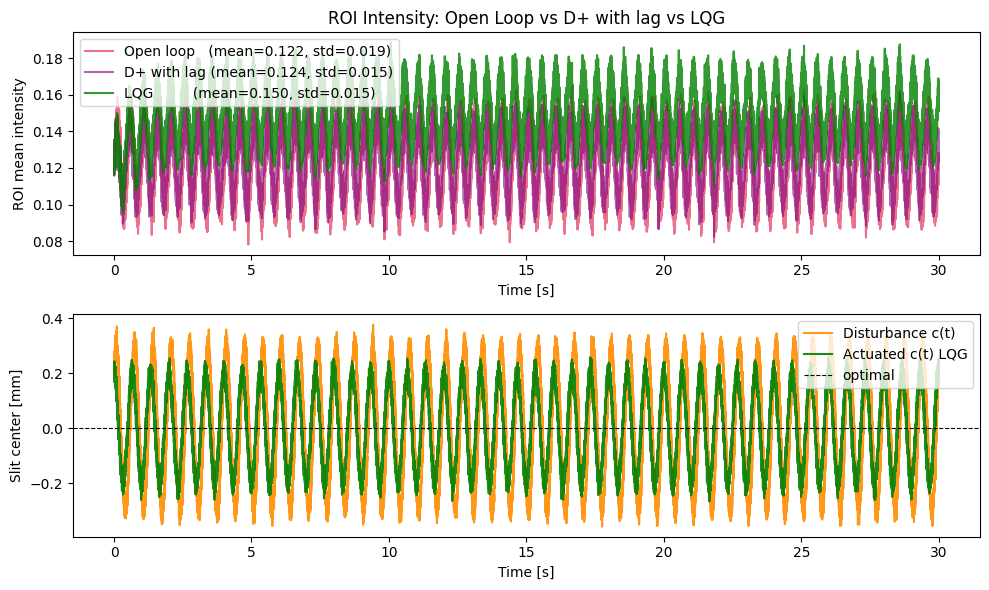

Open loop   — mean: 0.1224, std: 0.0186
D+ with lag — mean: 0.1235, std: 0.0147
LQG         — mean: 0.1501, std: 0.0150


In [45]:
from scipy.linalg import expm

# ── Block 9: LQG Controller ───────────────────────────────────

# ── Disturbance frequencies from PSD ─────────────────────────
wc = 2*np.pi*1.5    # center disturbance [rad/s]
wa = 2*np.pi*2.0    # width disturbance [rad/s]

# ── Continuous time A and C matrices ─────────────────────────
A_ct = np.array([[0,      1,  0,      0],
                 [-wc**2, 0,  0,      0],
                 [0,      0,  0,      1],
                 [0,      0, -wa**2,  0]])

C = np.array([[1, 0, 0, 0],
              [0, 0, 1, 0]])

# ── Discretize A ─────────────────────────────────────────────
A_d = expm(A_ct * dt)

# ── Noise covariance matrices ─────────────────────────────────
Q = np.diag([1e-6, 1e-6, 1e-8, 1e-8])
R = np.diag([1e-8, 1e-8])

# ── Steady state Kalman gain (iterative Riccati) ──────────────
P = np.eye(4) * 1e-6
for _ in range(2000):
    P_pred = A_d @ P @ A_d.T + Q
    S      = C @ P_pred @ C.T + R
    K_kal  = P_pred @ C.T @ np.linalg.inv(S)
    P      = (np.eye(4) - K_kal @ C) @ P_pred

print("Kalman gain K_kal:")
print(np.round(K_kal, 6))

# ── Simulation ────────────────────────────────────────────────
np.random.seed(42)

c_actuator = 0.0
a_actuator = 0.0
x_hat      = np.zeros(4)

a_lqg_log   = np.zeros(len(time))
c_lqg_log   = np.zeros(len(time))
c_act_log   = np.zeros(len(time))
roi_lqg_log = np.zeros(len(time))

for i, t in enumerate(time):
    # step 1: disturbance moves the slit
    a_dist, c_dist = disturbed_slit(t)

    # step 2: measurement
    y = np.array([c_dist, a_dist])

    # step 3: Kalman predict + update
    y_pred = C @ x_hat
    x_hat  = A_d @ x_hat + K_kal @ (y - y_pred)

    # step 4: feedforward — negate estimated disturbance
    u_c = -x_hat[0]           # cancel estimated center disturbance
    u_a = -(x_hat[2] - a0)    # cancel estimated width disturbance

    # step 5: actuator lag
    c_actuator = alpha_c * c_actuator + (1 - alpha_c) * u_c
    a_actuator = alpha_a * a_actuator + (1 - alpha_a) * u_a

    # step 6: apply correction
    c_act = c_dist + c_actuator
    a_act = np.clip(a_dist + a_actuator, 0.05e-3, 2e-3)

    # step 7: measure intensity
    I = intensity(x, a_act, c_act, lam, f)

    a_lqg_log[i]   = a_act
    c_lqg_log[i]   = c_dist
    c_act_log[i]   = c_act
    roi_lqg_log[i] = I[roi_mask].mean()

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 6), tight_layout=True)

axes[0].plot(time, roi_log,     color='crimson', alpha=0.6,
             label=f'Open loop   (mean={roi_log.mean():.3f}, std={roi_log.std():.3f})')
axes[0].plot(time, roi_lag_log, color='purple',  alpha=0.6,
             label=f'D+ with lag (mean={roi_lag_log.mean():.3f}, std={roi_lag_log.std():.3f})')
axes[0].plot(time, roi_lqg_log, color='green',   alpha=0.8,
             label=f'LQG         (mean={roi_lqg_log.mean():.3f}, std={roi_lqg_log.std():.3f})')
axes[0].set_ylabel('ROI mean intensity')
axes[0].set_xlabel('Time [s]')
axes[0].legend()
axes[0].set_title('ROI Intensity: Open Loop vs D+ with lag vs LQG')

axes[1].plot(time, c_lqg_log*1e3, color='darkorange', alpha=0.9, label='Disturbance c(t)')
axes[1].plot(time, c_act_log*1e3, color='green',      alpha=0.9, label='Actuated c(t) LQG')
axes[1].axhline(0, color='k', linestyle='--', linewidth=0.8, label='optimal')
axes[1].set_ylabel('Slit center [mm]')
axes[1].set_xlabel('Time [s]')
axes[1].legend()

plt.savefig('lqg_control.png', dpi=150)
plt.show()

print(f"Open loop   — mean: {roi_log.mean():.4f}, std: {roi_log.std():.4f}")
print(f"D+ with lag — mean: {roi_lag_log.mean():.4f}, std: {roi_lag_log.std():.4f}")
print(f"LQG         — mean: {roi_lqg_log.mean():.4f}, std: {roi_lqg_log.std():.4f}")